In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import torch
import random
from itertools import combinations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Prepare Evaluation

In [2]:
IMAGE_PATH = os.path.join('pet_biometric_challenge_2022', 'train', 'images')
DATA_PATH = os.path.join('pet_biometric_challenge_2022', 'train')
CSV_PATH = os.path.join(DATA_PATH, 'validation_from_train.csv')

In [3]:
df = pd.read_csv(CSV_PATH)
df

,imageA,imageB,labels
0,A_nWbqS54ejJYAAAAAAAAAAAAAAQAAAQ.jpg,A_eqVVQqqu89gAAAAAAAAAAAAAAQAAAQ.jpg,0
1,A_GH6tT4KsGsAAAAAAAAAAAAAAAQAAAQ.jpg,A_lzcXSqsruF4AAAAAAAAAAAAAAQAAAQ.jpg,1
2,Yh4KHqgtR2eecVl-P4N5LwAAACMAARAD.jpg,1Cxhvj2kRTaTE7bL8MnjgQAAACMAARAD.jpg,1
3,4XLT9us-QKC9CLt1PyczfwAAACMAARAD.jpg,QBVPgfagSrmRib_t9X9NfAAAACMAARAD.jpg,1
4,A_I3N-R6v9tQcAAAAAAAAAAAAAAQAAAQ.jpg,A_cMQ4TLREtygAAAAAAAAAAAAAAQAAAQ.jpg,1
...,...,...,...
995,kfV661fXTRWkcoziE6QSfAAAACMAARAD.jpg,A_SWr2T4wdFb0AAAAAAAAAAAAAAQAAAQ.jpg,0
996,7acgIydjTzSRdRI7JrDCNgAAACMAARAD.jpg,__p5YavdTOaSktF2o7CxiwAAACMAARAD.jpg,0
997,on_ZpPM-S9WHmlUxYg2zfAAAACMAARED.jpg,A_doCUQZkA6ggAAAAAAAAAAAAAAQAAAQ.jpg,0
998,A_h31qT5pnH3sAAAAAAAAAAAAAAQAAAQ.jpg,A_NB8oQbPKPLUAAAAAAAAAAAAAAQAAAQ.jpg,0


In [4]:
val_pairs = [tuple(row) for row in df.values]
val_pairs

[('A_nWbqS54ejJYAAAAAAAAAAAAAAQAAAQ.jpg',
  'A_eqVVQqqu89gAAAAAAAAAAAAAAQAAAQ.jpg',
  0),
 ('A_GH6tT4KsGsAAAAAAAAAAAAAAAQAAAQ.jpg',
  'A_lzcXSqsruF4AAAAAAAAAAAAAAQAAAQ.jpg',
  1),
 ('Yh4KHqgtR2eecVl-P4N5LwAAACMAARAD.jpg',
  '1Cxhvj2kRTaTE7bL8MnjgQAAACMAARAD.jpg',
  1),
 ('4XLT9us-QKC9CLt1PyczfwAAACMAARAD.jpg',
  'QBVPgfagSrmRib_t9X9NfAAAACMAARAD.jpg',
  1),
 ('A_I3N-R6v9tQcAAAAAAAAAAAAAAQAAAQ.jpg',
  'A_cMQ4TLREtygAAAAAAAAAAAAAAQAAAQ.jpg',
  1),
 ('A_u3ITRZRS34IAAAAAAAAAAAAAAQAAAQ.jpg',
  'A_FViyQKVTUJEAAAAAAAAAAAAAAQAAAQ.jpg',
  1),
 ('A_T58ARY_Kmz4AAAAAAAAAAAAAAQAAAQ.jpg',
  'A_4O90SKrydJMAAAAAAAAAAAAAAQAAAQ.jpg',
  1),
 ('YOBroeTpR4u94j0Q2MDmOgAAACMAARAD.jpg',
  '1xB4LZXbT8SCNlWnwZg0MgAAACMAARED.jpg',
  1),
 ('A_V-dARau9w5gAAAAAAAAAAAAAAQAAAQ.jpg',
  'A_rItsSp90WNEAAAAAAAAAAAAAAQAAAQ.jpg',
  0),
 ('A_e1KlTqDhLGoAAAAAAAAAAAAAAQAAAQ.jpg',
  'A_vKbaQJDnZtYAAAAAAAAAAAAAAQAAAQ.jpg',
  0),
 ('A_-u9tR5lveQ4AAAAAAAAAAAAAAQAAAQ.jpg',
  'A_jU0bRZhgCSsAAAAAAAAAAAAAAQAAAQ.jpg',
  1),
 ('A_oiNNQ

In [5]:
class SiameseDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]
        
        img1_full = os.path.join(IMAGE_PATH, img1_path)
        img2_full = os.path.join(IMAGE_PATH, img2_path)
        try:
            img1 = Image.open(img1_full).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error loading image: {img1_full} — {e}")

        try:
            img2 = Image.open(img2_full).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error loading image: {img2_full} — {e}")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32), img1_path, img2_path

In [6]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [7]:
val_dataset = SiameseDataset(val_pairs,val_transform)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

In [8]:
image1, image2, labels, path1, path2 = next(iter(val_loader))
path1

('A_nWbqS54ejJYAAAAAAAAAAAAAAQAAAQ.jpg',
 'A_GH6tT4KsGsAAAAAAAAAAAAAAAQAAAQ.jpg',
 'Yh4KHqgtR2eecVl-P4N5LwAAACMAARAD.jpg',
 '4XLT9us-QKC9CLt1PyczfwAAACMAARAD.jpg',
 'A_I3N-R6v9tQcAAAAAAAAAAAAAAQAAAQ.jpg',
 'A_u3ITRZRS34IAAAAAAAAAAAAAAQAAAQ.jpg',
 'A_T58ARY_Kmz4AAAAAAAAAAAAAAQAAAQ.jpg',
 'YOBroeTpR4u94j0Q2MDmOgAAACMAARAD.jpg',
 'A_V-dARau9w5gAAAAAAAAAAAAAAQAAAQ.jpg',
 'A_e1KlTqDhLGoAAAAAAAAAAAAAAQAAAQ.jpg',
 'A_-u9tR5lveQ4AAAAAAAAAAAAAAQAAAQ.jpg',
 'A_oiNNQq82Sm4AAAAAAAAAAAAAAQAAAQ.jpg',
 'A_GHAbSKWvcZwAAAAAAAAAAAAAAQAAAQ.jpg',
 'mIKknZGLTlSuFDDxtGrMJgAAACMAARAD.jpg',
 'A_BB02QaOuIT4AAAAAAAAAAAAAAQAAAQ.jpg',
 'OuN9OzXCRwiYPj0wLisEZAAAACMAARAD.jpg')

# Prepare Network

In [9]:
import torch.nn as nn
import torchvision.models as models

class ResNet50_Backbone(nn.Module):
    def __init__(self):
        super(ResNet50_Backbone, self).__init__()

        resnet = models.resnet50()

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        self.extra_layers = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.extra_layers(x)
        return x


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PositionAttentionModule(nn.Module):
    ''' self-attention '''

    def __init__(self, in_channels):
        super().__init__()
        self.query_conv = nn.Conv2d(
            in_channels, in_channels // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        """
        inputs :
            x : feature maps from feature extractor. (N, C, H, W)
        outputs :
            feature maps weighted by attention along spatial dimensions
        """

        N, C, H, W = x.shape
        query = self.query_conv(x).view(
            N, -1, H*W).permute(0, 2, 1)  # (N, H*W, C')
        key = self.key_conv(x).view(N, -1, H*W)  # (N, C', H*W)

        # caluculate correlation
        energy = torch.bmm(query, key)    # (N, H*W, H*W)
        # spatial normalize
        attention = self.softmax(energy)

        value = self.value_conv(x).view(N, -1, H*W)    # (N, C, H*W)

        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(N, C, H, W)
        out = self.gamma*out + x
        return out


class ChannelAttentionModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        """
        inputs :
            x : feature maps from feature extractor. (N, C, H, W)
        outputs :
            feature maps weighted by attention along a channel dimension
        """

        N, C, H, W = x.shape
        query = x.view(N, C, -1)    # (N, C, H*W)
        key = x.view(N, C, -1).permute(0, 2, 1)    # (N, H*W, C)

        # calculate correlation
        energy = torch.bmm(query, key)    # (N, C, C)
        energy = torch.max(
            energy, -1, keepdim=True)[0].expand_as(energy) - energy
        attention = self.softmax(energy)

        value = x.view(N, C, -1)

        out = torch.bmm(attention, value)
        out = out.view(N, C, H, W)
        out = self.gamma*out + x
        return out


class DualAttentionModule(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.pam = PositionAttentionModule(in_channels)
        self.cam = ChannelAttentionModule()

    def forward(self, x):
        pam_out = self.pam(x)  
        cam_out = self.cam(x)  

        out = torch.cat([cam_out, pam_out, x], dim=1)
        return out


In [11]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=1024):
        """
        embedding_dim: final embedding dimension (paper uses 1024)
        """
        super().__init__()
        self.feature_extractor = ResNet50_Backbone()  # outputs (B,512,H,W)
        self.dam = DualAttentionModule(in_channels=512)  # outputs (B,1024,H,W)
        self.gap = nn.AdaptiveAvgPool2d((1,1))           

        self.fc = nn.Linear(3*512, embedding_dim, bias=False)  
        self.bn = nn.BatchNorm1d(embedding_dim)

    def embed(self, x):
        x = self.feature_extractor(x)   # (B,512,H,W)
        x = self.dam(x)                 # (B,1024,H,W)
        x = self.gap(x)                 # (B,1024,1,1)
        x = x.view(x.size(0), -1)       # (B,1024)
        x = self.fc(x)                  # (B, embedding_dim) (paper uses 1024)
        x = self.bn(x)

        x = F.normalize(x, p=2, dim=1)
        return x

    def forward(self, img1, img2):
        emb1 = self.embed(img1)
        emb2 = self.embed(img2)
        return emb1, emb2

# Load Model

In [13]:
model = SiameseNetwork()
model.load_state_dict(torch.load("pet_biometric_challenge_2022/DNNet+Conloss.h5", map_location=torch.device('cuda')))
model.eval()

SiameseNetwork(
  (feature_extractor): ResNet50_Backbone(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): R

In [16]:
result = []

In [18]:
with torch.no_grad():
    for (img1, img2, labels, img1_path, img2_path) in val_loader:
        pred1, pred2 = model(img1, img2)
        similarity = F.cosine_similarity(pred1, pred2)
        print(f"Label: {labels}\nSimilarity: {similarity}\n------------------------------------------------")
        for i in range(len(img1_path)):
            result.append((img1_path[i], img2_path[i], labels[i], similarity[i]))


Label: tensor([0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1.])
Similarity: tensor([ 0.3588,  0.6894,  0.4081,  0.9638,  0.9475,  0.9499,  0.7288,  1.0000,
         0.5228,  0.4449,  0.9056, -0.4007,  0.9498,  0.3872,  0.0552,  0.9241])
------------------------------------------------
Label: tensor([1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1.])
Similarity: tensor([ 0.4596,  0.4582,  0.8797,  0.6309,  0.4343,  0.1285, -0.0267,  0.9806,
        -0.1777,  0.9794,  0.7781,  0.9942,  0.9732,  0.7731,  0.5863,  0.8348])
------------------------------------------------
Label: tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.])
Similarity: tensor([ 0.5640,  0.7576,  0.5612,  0.8901,  0.2176,  0.5780, -0.0011,  0.9773,
         0.3127, -0.6297,  0.7217,  1.0000,  0.7526,  0.5421,  0.6245,  0.5183])
------------------------------------------------
Label: tensor([1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1.])
Similarity: te

In [19]:
pred_df = pd.DataFrame(result, columns=['imageA', 'imageB', 'labels', 'similarity'])
pred_df.to_csv("pred_Resnet50_DAM_contrastive.csv")

In [21]:
from sklearn.metrics import roc_auc_score
import pandas as pd

df = pd.read_csv("pred_Resnet50_DAM_contrastive.csv") 

df['labels'] = pd.to_numeric(df['labels'])
df['similarity'] = pd.to_numeric(df['similarity'])

auc = roc_auc_score(df['labels'], df['similarity'])
print(f"ROC AUC Score: {auc:.4f}")

ROC AUC Score: 0.8421


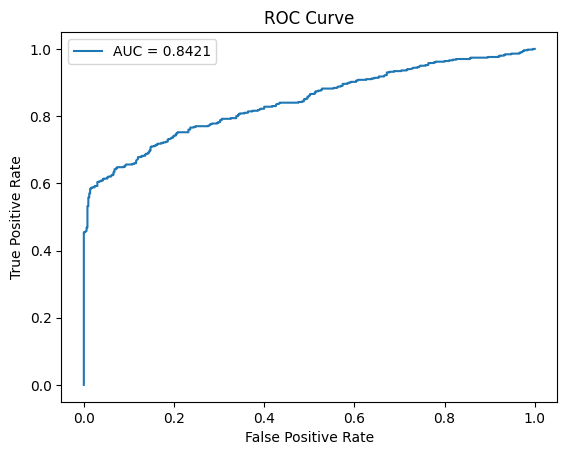

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(df['labels'], df['similarity'])
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(df['labels'], df['similarity'])

best_idx = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.4f}")


Best threshold: 0.7099


In [24]:
df['pred'] = (df['similarity'] >= best_threshold).astype(int)


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(df['labels'], df['pred']))
print("Precision:", precision_score(df['labels'], df['pred']))
print("Recall:", recall_score(df['labels'], df['pred']))
print("F1 Score:", f1_score(df['labels'], df['pred']))


Accuracy: 0.787
Precision: 0.9042253521126761
Recall: 0.642
F1 Score: 0.7508771929824561
